# Comparison of Local Context Correlations: All Documents vs. Citable Documents

This notebook performs a systematic comparison between the correlations calculated for **All Documents** and **Citable Documents** in the Local Context across different OpenAlex Topics.



In [2]:
#Montar mi google drive para poder usar los archivos
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:

%cd "/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/OpenAlex/LocalContext/"
!ls

/content/gdrive/.shortcut-targets-by-id/0B5aSrRJgnViLfm9LWl9TY21TWm5wSU0zbkgzc2YyeEp3RzJMaEJOR2FWbFkxVEZYTjNQd1E/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/OpenAlex/LocalContext
ai.txt
AMEASURE.txt
figuras
FMEASURE.txt
GAggregation.txt
GMEASURE.txt
ManuscriptActivityIndexFmeasure_ESI_LocalContext.ipynb
manuscriptFiguresAndTables.html
pearson_correlation_AI_FMeasure.csv
rsi.txt
scatterplots
scatterplots.html
share.txt
Spearman_correlation_AI_FMeasure.csv
Wshare.txt


In [4]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'figure.titlesize': 14,
    'figure.titleweight': 'bold'
})


In [5]:
# Define paths to the CSV files
paths = {
    'all_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/OpenAlex/LocalContext/pearson_correlation_AI_FMeasure.csv',
    'all_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments/OpenAlex/LocalContext/Spearman_correlation_AI_FMeasure.csv',
    'citable_pearson': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments2026/OpenAlex/LocalContext/pearson_correlation_AI_FMeasure.csv',
    'citable_spearman': r'/content/gdrive/My Drive/Ciencias/Data/WoS/InCites/ESI/ManuscriptExperiments2026/OpenAlex/LocalContext/Spearman_correlation_AI_FMeasure.csv'
}

# Load files
dfs = {}
for name, path in paths.items():
    if not os.path.exists(path):
        # Try relative paths as fallback
        if '2026' in path:
            rel_path = f'Global Context/{os.path.basename(path)}'
        else:
            rel_path = f'../../ManuscriptExperiments/Global Context/{os.path.basename(path)}'
        if os.path.exists(rel_path):
            path = rel_path

    dfs[name] = pd.read_csv(path, index_col=0)
    print(f"Successfully loaded {name} (Shape: {dfs[name].shape})")


Successfully loaded all_pearson (Shape: (247, 11))
Successfully loaded all_spearman (Shape: (247, 10))
Successfully loaded citable_pearson (Shape: (247, 11))
Successfully loaded citable_spearman (Shape: (247, 10))


In [6]:
def get_comparison_table(col_name):
    """
    Creates a side-by-side comparison table for a specific correlation column.
    """
    # Base index of ESI fields from the Pearson All dataset
    index_ref = dfs['all_pearson'].index

    df_comp = pd.DataFrame(index=index_ref)

    # Pearson
    df_comp['Pearson (All)'] = dfs['all_pearson'][col_name]
    df_comp['Pearson (Citable)'] = dfs['citable_pearson'][col_name]
    df_comp['Pearson Diff (Citable - All)'] = df_comp['Pearson (Citable)'] - df_comp['Pearson (All)']

    # Spearman (aligning indices)
    df_comp['Spearman (All)'] = df_comp.index.map(dfs['all_spearman'][col_name])
    df_comp['Spearman (Citable)'] = df_comp.index.map(dfs['citable_spearman'][col_name])
    df_comp['Spearman Diff (Citable - All)'] = df_comp['Spearman (Citable)'] - df_comp['Spearman (All)']

    # Sort ESI Fields alphabetically
    df_comp = df_comp.sort_index()
    return df_comp

def display_styled_table(df, title):
    """
    Applies advanced pandas styler to color-code difference columns and display.
    """
    styled = df.style.format("{:.4f}")\
        .background_gradient(cmap="coolwarm", subset=["Pearson Diff (Citable - All)", "Spearman Diff (Citable - All)"], vmin=-0.2, vmax=0.2)\
        .set_caption(f"<b style='font-size: 14px;'>{title}</b>")\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f4f6f7'), ('color', '#2c3e50'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'right')]},
            {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
        ])
    display(styled)

def plot_comparison(df, user_name):
    """
    Generates side-by-side horizontal bar plots to visualize the differences in correlations.
    """
    # Prepare Pearson data for Seaborn
    df_pearson = pd.DataFrame({
        'ESI Field': df.index,
        'All Documents': df['Pearson (All)'].values,
        'Citable Documents': df['Pearson (Citable)'].values
    }).melt(id_vars='ESI Field', var_name='Dataset', value_name='Pearson Correlation')

    # Prepare Spearman data for Seaborn
    df_spearman = pd.DataFrame({
        'ESI Field': df.index,
        'All Documents': df['Spearman (All)'].values,
        'Citable Documents': df['Spearman (Citable)'].values
    }).melt(id_vars='ESI Field', var_name='Dataset', value_name='Spearman Correlation')

    fig, axes = plt.subplots(1, 2, figsize=(16, 49), sharey=True)

    # Harmonious colors: Cool Blue for All, Warm Coral for Citable
    colors = {'All Documents': '#2b7bba', 'Citable Documents': '#e76f51'}

    # Pearson Subplot
    sns.barplot(
        data=df_pearson,
        y='ESI Field',
        x='Pearson Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[0]
    )
    axes[0].set_title("Pearson Correlation Coefficient", fontsize=13, pad=10)
    axes[0].set_xlabel("Correlation Value")
    axes[0].set_ylabel("ESI Field")
    axes[0].set_xlim(-1.05, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[0].legend().set_visible(False)

    # Spearman Subplot
    sns.barplot(
        data=df_spearman,
        y='ESI Field',
        x='Spearman Correlation',
        hue='Dataset',
        palette=colors,
        ax=axes[1]
    )
    axes[1].set_title("Spearman Correlation Coefficient", fontsize=13, pad=10)
    axes[1].set_xlabel("Correlation Value")
    axes[1].set_ylabel("")
    axes[1].set_xlim(-1.05, 1.05)
    axes[1].grid(True, linestyle="--", alpha=0.6, axis='x')
    axes[1].legend().set_visible(False)

    # Add single common legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2, fontsize=11)

    plt.suptitle(f"Correlation Comparison: {user_name} (All vs. Citable)", fontsize=15, y=1.03)
    plt.tight_layout()
    plt.show()


## 1. AI vs DShareC Correlation Comparison

This section compares the Pearson and Spearman correlations of **Activity Index (AI)** versus **DShareC**.
This indicator measures how the proportion of publications (AI) relates to the document share in the citation distribution.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
JE,0.9604,0.9103,-0.0501,0.9487,0.6925,-0.2561
GW,0.3042,0.2003,-0.1039,0.8295,0.6130,-0.2166
VG,0.5060,0.3250,-0.1810,0.7684,0.0489,-0.7195
GM,0.3248,0.2527,-0.0721,0.7556,0.6253,-0.1303
ID,0.6800,0.7238,0.0438,0.7552,0.7962,0.0410
PA,0.5334,0.5488,0.0154,0.7475,0.7197,-0.0278
KN,0.0641,0.1505,0.0863,0.7385,0.6649,-0.0737
RE,0.6229,0.5185,-0.1044,0.7240,0.7849,0.0609
GL,0.7842,0.6363,-0.1479,0.7215,0.5640,-0.1576
MQ,0.7934,0.6308,-0.1626,0.7149,0.5286,-0.1863


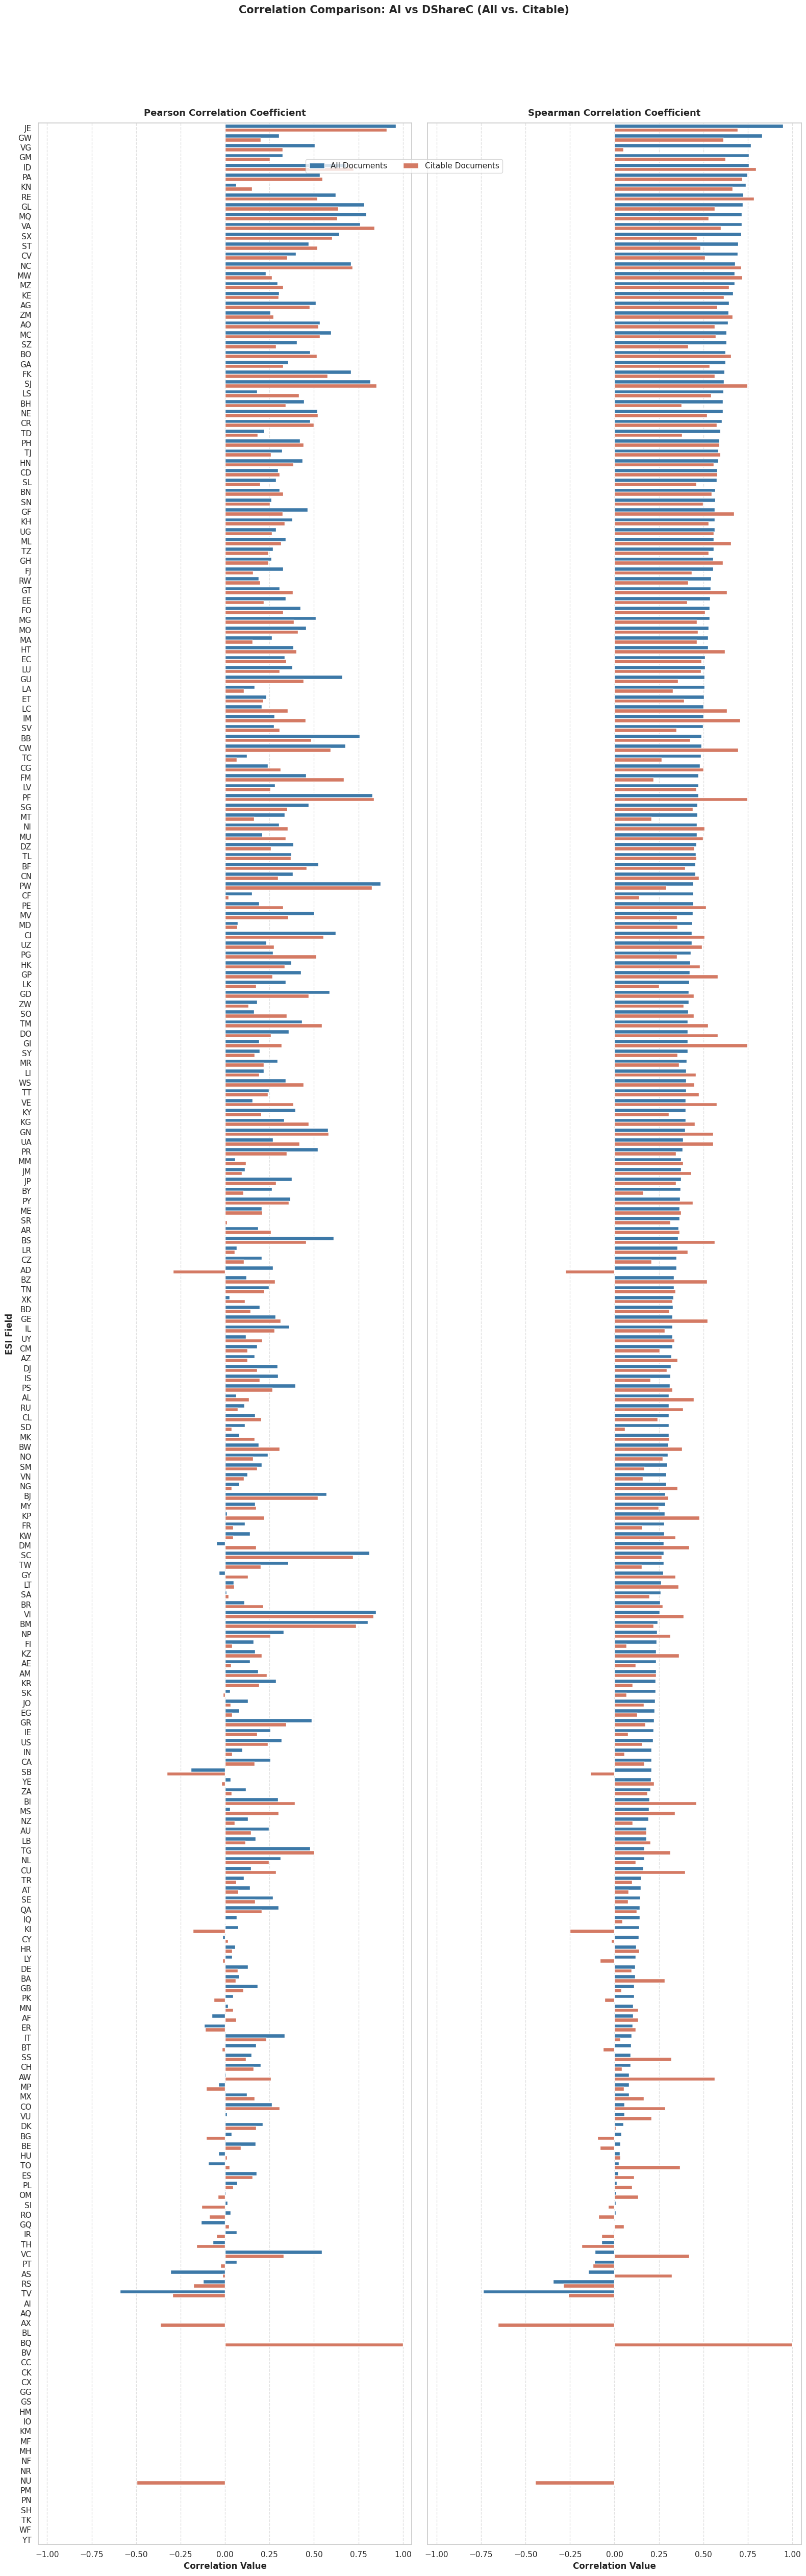

In [7]:
df_ai_dsharec = get_comparison_table('AI vs DShareC')
display_styled_table(df_ai_dsharec.sort_values('Spearman (All)', ascending=False), 'Table 1: AI vs DShareC (All vs. Citable)')
plot_comparison(df_ai_dsharec.sort_values('Spearman (All)', ascending=False), 'AI vs DShareC')


## 2. AI vs CShareD Correlation Comparison

This section compares the correlations of **Activity Index (AI)** versus **CShareD**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
AD,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AE,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AF,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AG,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AL,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AM,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AO,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AR,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AS,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
AT,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000


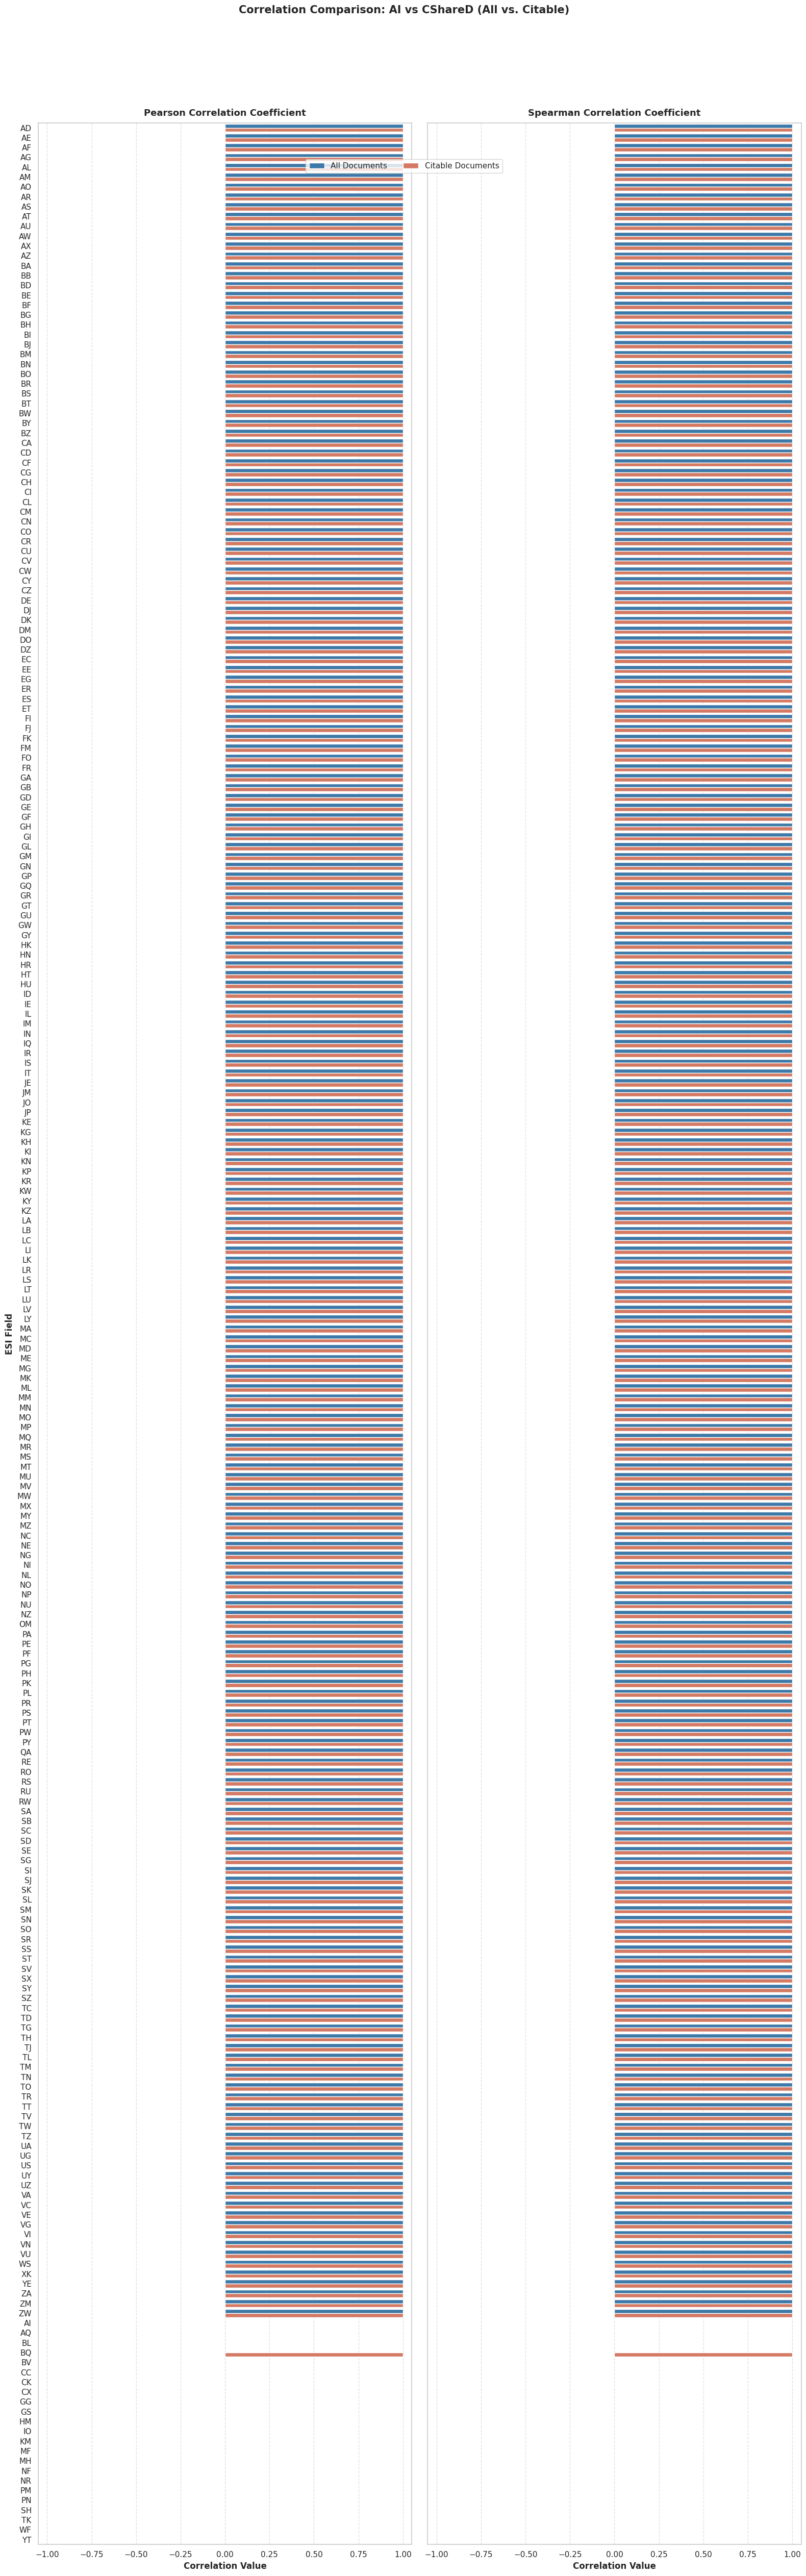

In [8]:
df_ai_cshared = get_comparison_table('AI vs CShareD')
display_styled_table(df_ai_cshared.sort_values('Spearman (All)', ascending=False), 'Table 2: AI vs CShareD (All vs. Citable)')
plot_comparison(df_ai_cshared.sort_values('Spearman (All)', ascending=False), 'AI vs CShareD')


## 3. F-Measure vs DShareC (ShareC) Correlation Comparison

This section compares the correlations of **F-Measure** versus **DShareC**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
US,0.9519,0.9744,0.0225,0.9938,0.9966,0.0027
ID,0.8607,0.9427,0.0820,0.9802,0.9850,0.0048
CN,0.9706,0.9745,0.0039,0.9740,0.9938,0.0198
GB,0.8449,0.8655,0.0206,0.9624,0.9597,-0.0027
JE,0.9604,0.9103,-0.0501,0.9487,0.6925,-0.2561
FR,0.6857,0.6985,0.0128,0.9439,0.9373,-0.0067
IN,0.8701,0.8740,0.0039,0.9337,0.9494,0.0157
CA,0.7477,0.7674,0.0197,0.9227,0.9186,-0.0041
AU,0.7350,0.7432,0.0082,0.9186,0.9350,0.0164
DE,0.7514,0.7419,-0.0095,0.9179,0.9357,0.0178


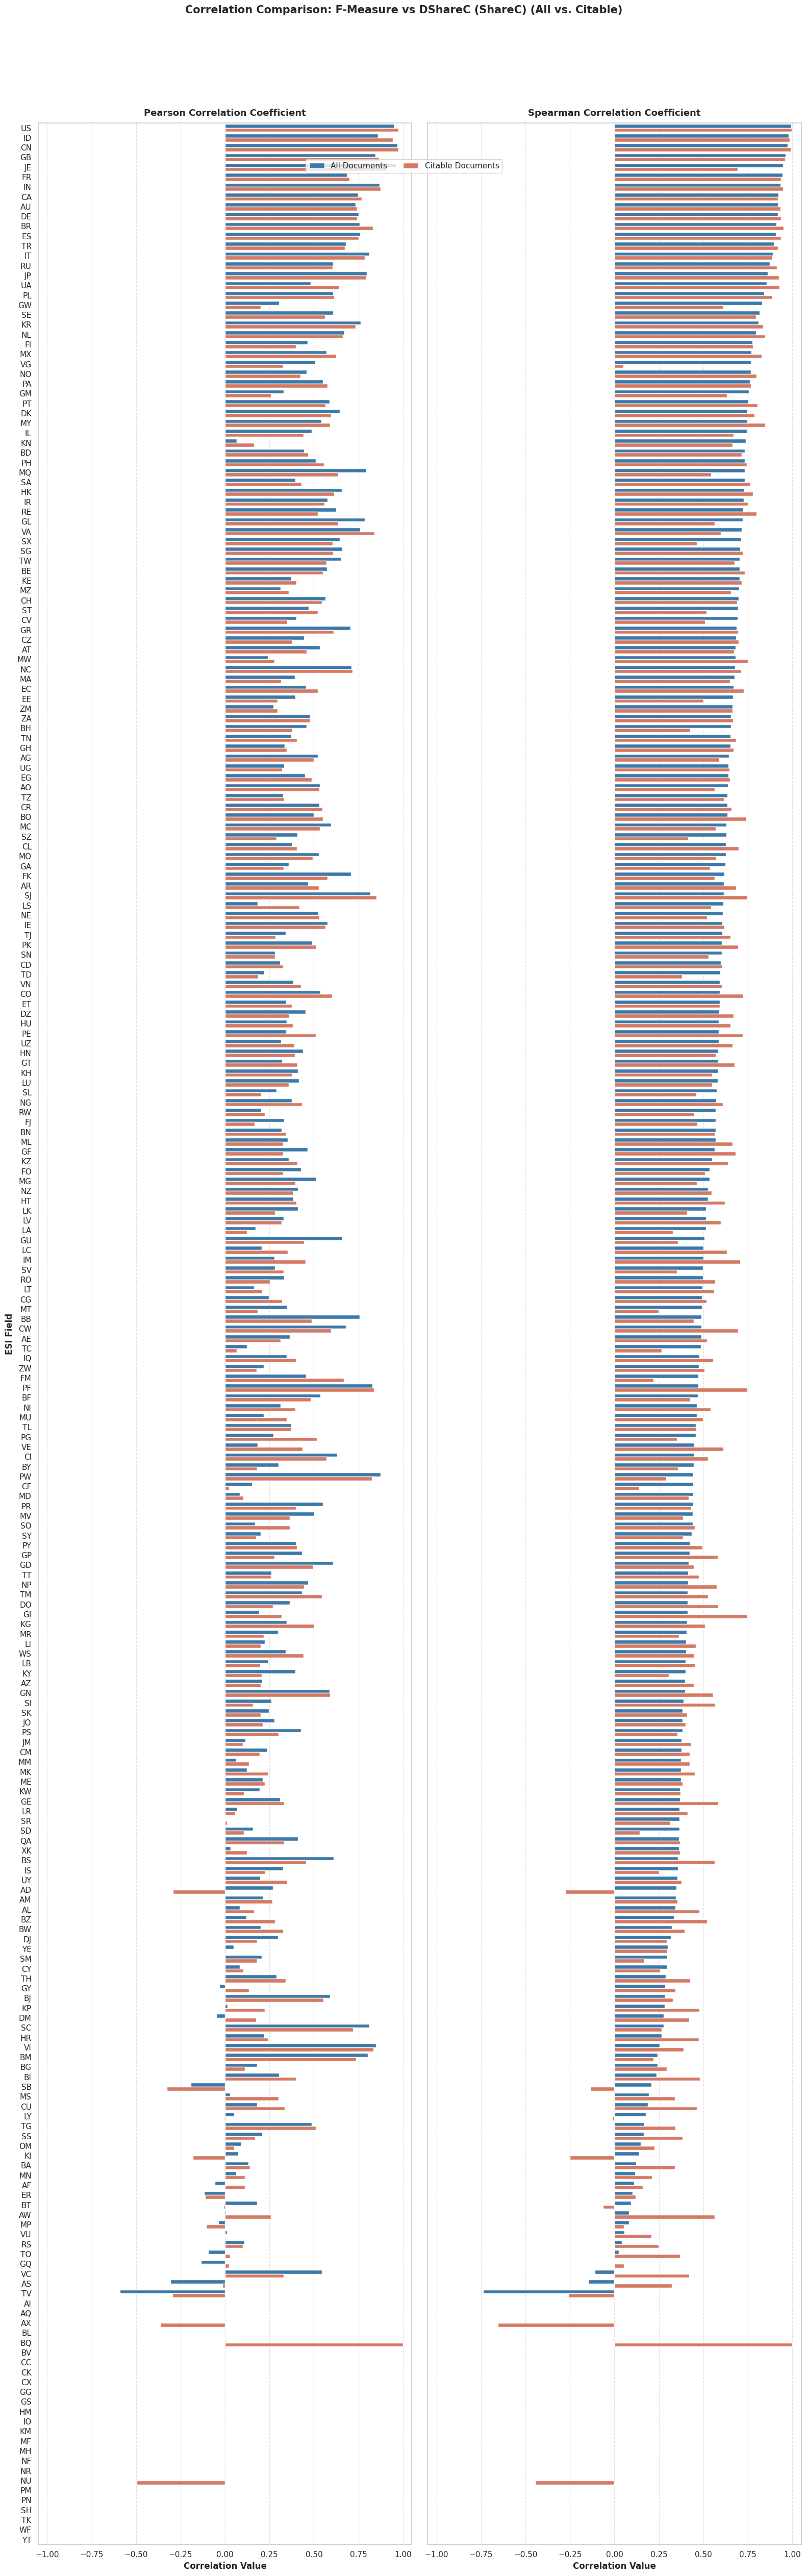

In [9]:
df_f_dsharec = get_comparison_table('F-Measure vs DShareC')
display_styled_table(df_f_dsharec.sort_values('Spearman (All)', ascending=False), 'Table 3: F-Measure vs DShareC (All vs. Citable)')
plot_comparison(df_f_dsharec.sort_values('Spearman (All)', ascending=False), 'F-Measure vs DShareC (ShareC)')


## 4. F-Measure vs CShareD Correlation Comparison

This section compares the correlations of **F-Measure** versus **CShareD**.


,Pearson (All),Pearson (Citable),Pearson Diff (Citable - All),Spearman (All),Spearman (Citable),Spearman Diff (Citable - All)
AD,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
AG,0.9998,0.9994,-0.0004,1.0000,0.9992,-0.0008
AO,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
AS,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
AX,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
BB,1.0000,1.0000,-0.0000,1.0000,0.9987,-0.0013
AW,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000
BJ,0.9990,0.9973,-0.0017,1.0000,0.9979,-0.0021
BS,1.0000,1.0000,-0.0000,1.0000,1.0000,0.0000
BT,0.9999,0.9998,-0.0001,1.0000,1.0000,0.0000


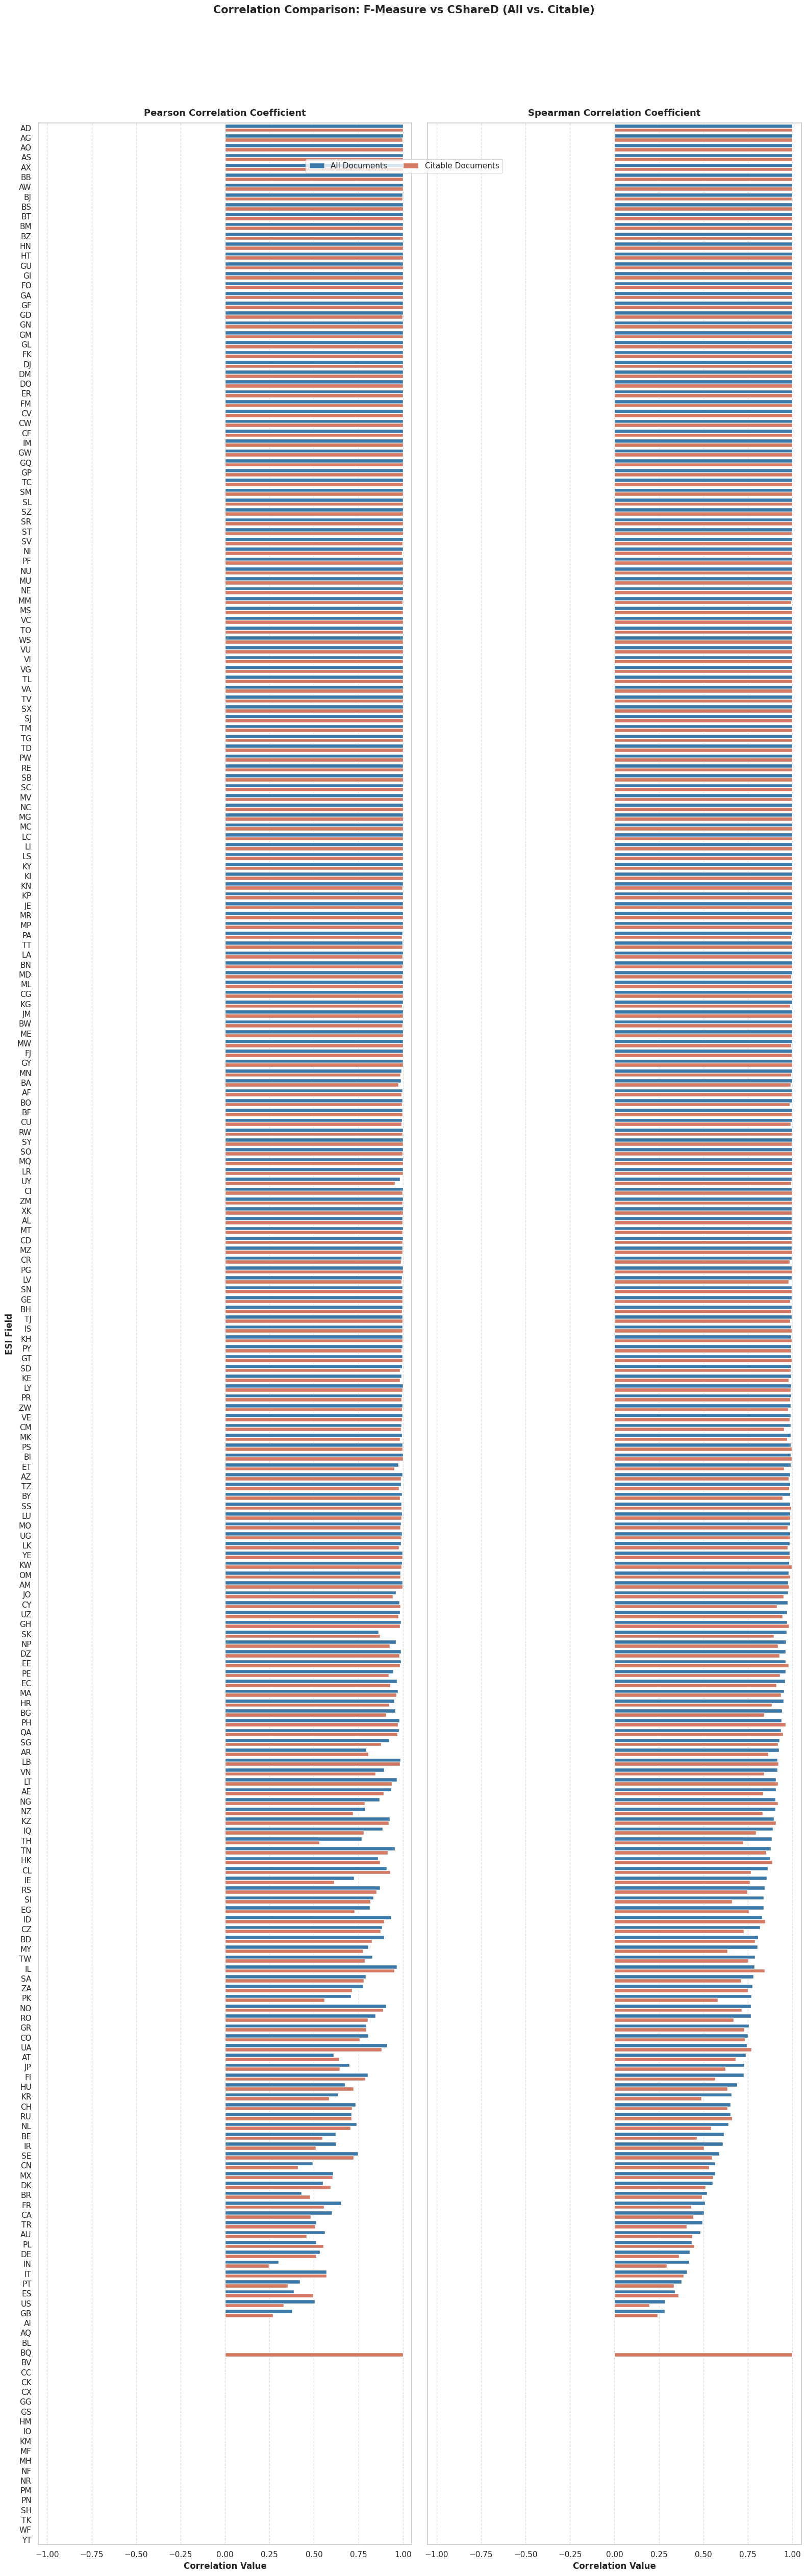

In [10]:
df_f_cshared = get_comparison_table('F-Measure vs CShareD')
display_styled_table(df_f_cshared.sort_values('Spearman (All)', ascending=False), 'Table 4: F-Measure vs CShareD (All vs. Citable)')
plot_comparison(df_f_cshared.sort_values('Spearman (All)', ascending=False), 'F-Measure vs CShareD')


## 5. Summary Statistics and Overall Analysis (Absolute Discrepancies)

To synthesize the comparison, let's look at the summary statistics of the **absolute differences** across all 22 ESI fields for each of the four indicator pairs.

Using absolute values is essential because it measures the magnitude of the discrepancy (change) regardless of whether the correlation went up or down. For example, a large negative change like -0.76708 represents a major discrepancy of 0.76708 in absolute terms. Computing statistics on signed differences can cause positive and negative changes to cancel each other out, hiding the true extent of the changes.


In [11]:
summary_data = []
pairs_mapping = {
    'AI vs DShareC': 'AI vs DShareC',
    'AI vs CShareD': 'AI vs CShareD',
    'F-Measure vs DShareC': 'F-Measure vs DShareC',
    'F-Measure vs CShareD': 'F-Measure vs CShareD'
}

for user_name, csv_name in pairs_mapping.items():
    df_p = get_comparison_table(csv_name)
    pearson_abs = df_p['Pearson Diff (Citable - All)'].abs()
    spearman_abs = df_p['Spearman Diff (Citable - All)'].abs()
    summary_data.append({
        'Indicator Pair': user_name,
        'Mean Abs Pearson Diff': pearson_abs.mean(),
        'Median Abs Pearson Diff': pearson_abs.median(),
        'Max Abs Pearson Diff': pearson_abs.max(),
        'Min Abs Pearson Diff': pearson_abs.min(),
        'Mean Abs Spearman Diff': spearman_abs.mean(),
        'Median Abs Spearman Diff': spearman_abs.median(),
        'Max Abs Spearman Diff': spearman_abs.max(),
        'Min Abs Spearman Diff': spearman_abs.min()
    })

df_summary = pd.DataFrame(summary_data).set_index('Indicator Pair')

styled_summary = df_summary.style.format("{:.5f}")\
    .background_gradient(cmap="Reds", vmin=0.0, vmax=0.3)\
    .set_caption("<b style='font-size: 14px;'>Overall Comparison Summary: Absolute Discrepancies (|Citable - All|)</b>")\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'right')]},
        {'selector': 'caption', 'props': [('margin-bottom', '10px'), ('color', '#2c3e50')]}
    ])
display(styled_summary)


,Mean Abs Pearson Diff,Median Abs Pearson Diff,Max Abs Pearson Diff,Min Abs Pearson Diff,Mean Abs Spearman Diff,Median Abs Spearman Diff,Max Abs Spearman Diff,Min Abs Spearman Diff
Indicator Pair,,,,,,,,
AI vs DShareC,0.08607,0.07184,0.56241,0.00163,0.10748,0.07224,0.71949,0.00026
AI vs CShareD,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
F-Measure vs DShareC,0.07679,0.05250,0.56242,0.00006,0.09894,0.06194,0.71949,0.00068
F-Measure vs CShareD,0.01613,0.00097,0.23705,0.00000,0.02178,0.00252,0.18872,0.00000
